# EDA - My Content : Exploration des donnees utilisateurs

Objectif : comprendre les donnees d'interaction utilisateur-article du portail Globo.com, preparer les matrices pour les modeles de recommandation.


## 1. Chargement et configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import glob
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Chemins
DATA_RAW = "../data/raw/"
DATA_PROC = "../data/processed/"
OUT = "../out/"
FIG = os.path.join(OUT, "figures")

os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

## 2. Chargement des donnees


### 2.1 Clicks complets


In [2]:
# Chargement de tous les fichiers clicks_hour_*.csv
click_files = sorted(glob.glob(os.path.join(DATA_RAW, "clicks_hour_*.csv")))
print(f"Fichiers trouves : {len(click_files)}")

if click_files:
    clicks = pd.concat([pd.read_csv(f) for f in click_files], ignore_index=True)
else:
    # Fallback sur le sample
    clicks = pd.read_csv(os.path.join(DATA_RAW, "clicks_sample.csv"))
    print("Fallback sur clicks_sample.csv")

print(f"Lignes : {len(clicks):,}")
print(f"Colonnes : {list(clicks.columns)}")
clicks.head()

Fichiers trouves : 385
Lignes : 2,988,181
Colonnes : ['user_id', 'session_id', 'session_start', 'session_size', 'click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


### 2.2 Metadonnees articles


In [3]:
articles = pd.read_csv(os.path.join(DATA_RAW, "articles_metadata.csv"))
print(f"Articles : {len(articles):,}")
articles.head()

Articles : 364,047


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


### 2.3 Embeddings articles


In [4]:
embeddings_path = os.path.join(DATA_RAW, "articles_embeddings.pickle")
if os.path.exists(embeddings_path):
    with open(embeddings_path, "rb") as f:
        embeddings = pickle.load(f)
    print(f"Type : {type(embeddings)}")
    print(f"Shape : {embeddings.shape}")
    print(f"Extrait :")
    print(embeddings.head() if hasattr(embeddings, 'head') else embeddings[:3])
else:
    print("Fichier embeddings non trouve")
    embeddings = None

/tmp/ipykernel_176786/2889874398.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  embeddings = pickle.load(f)


Type : <class 'numpy.ndarray'>
Shape : (364047, 250)
Extrait :
[[-0.16118301 -0.95723313 -0.13794445  0.05085534  0.83005524  0.90136534
  -0.33514765 -0.55956066 -0.50060284  0.16518293  0.4284342   0.3550556
   0.87443674 -0.52888286  0.6254872   0.2689198  -0.8228351  -0.703853
  -0.62584543 -0.15285493 -0.6662412   0.04329487  0.1786375   0.04689008
   0.5945311  -0.18334764  0.19510683 -0.46763963 -0.30480695  0.35317516
   0.27818817  0.5386231  -0.37120935  0.48989806 -0.10383289  0.11917368
   0.13243659 -0.62108386 -0.45331132  0.34662652 -0.06174106 -0.7305939
  -0.38411567 -0.94075835  0.06134219  0.4825816   0.28968322 -0.62269634
  -0.05000444  0.42151213 -0.24257636  0.6687105  -0.509004   -0.46179956
   0.04390178  0.28848746  0.4498246  -0.28486234  0.916729    0.70312876
   0.85167396 -0.6272441   0.35773164  0.3901894   0.65293527  0.1036527
   0.79829276 -0.10254639 -0.2045143   0.37861153 -0.09026147 -0.2511573
   0.3259828   0.08588007 -0.18056485  0.04752322 -0.15

## 3. Preparation des colonnes temporelles


In [5]:
# Conversion timestamps (millisecondes) en datetime
clicks["session_start_dt"] = pd.to_datetime(clicks["session_start"], unit="ms")
clicks["click_timestamp_dt"] = pd.to_datetime(clicks["click_timestamp"], unit="ms")

# Ajout de colonnes utiles
clicks["click_hour"] = clicks["click_timestamp_dt"].dt.hour
clicks["click_day"] = clicks["click_timestamp_dt"].dt.date
clicks["click_weekday"] = clicks["click_timestamp_dt"].dt.day_name()

articles["created_at_dt"] = pd.to_datetime(articles["created_at_ts"], unit="ms")

print("Plage temporelle clicks :")
print(f"  Debut : {clicks['click_timestamp_dt'].min()}")
print(f"  Fin   : {clicks['click_timestamp_dt'].max()}")
print(f"  Duree : {clicks['click_timestamp_dt'].max() - clicks['click_timestamp_dt'].min()}")

Plage temporelle clicks :
  Debut : 2017-10-01 03:00:00.026000
  Fin   : 2017-11-13 20:04:14.886000
  Duree : 43 days 17:04:14.860000


## 4. Statistiques globales


In [6]:
n_users = clicks["user_id"].nunique()
n_sessions = clicks["session_id"].nunique()
n_articles_clicked = clicks["click_article_id"].nunique()
n_articles_total = articles["article_id"].nunique()
n_categories = articles["category_id"].nunique()

stats = pd.DataFrame({
    "Metrique": [
        "Utilisateurs uniques",
        "Sessions uniques",
        "Interactions totales",
        "Articles cliques (distincts)",
        "Articles en base (total)",
        "Categories",
        "Clics moyen par user",
        "Clics moyen par session",
        "Taux de couverture articles"
    ],
    "Valeur": [
        f"{n_users:,}",
        f"{n_sessions:,}",
        f"{len(clicks):,}",
        f"{n_articles_clicked:,}",
        f"{n_articles_total:,}",
        f"{n_categories}",
        f"{len(clicks) / n_users:.1f}",
        f"{len(clicks) / n_sessions:.1f}",
        f"{n_articles_clicked / n_articles_total * 100:.2f}%"
    ]
})
stats

,Metrique,Valeur
0,Utilisateurs uniques,"322,897"
1,Sessions uniques,"1,048,594"
2,Interactions totales,"2,988,181"
3,Articles cliques (distincts),"46,033"
4,Articles en base (total),"364,047"
5,Categories,461
6,Clics moyen par user,9.3
7,Clics moyen par session,2.8
8,Taux de couverture articles,12.64%


## 5. Analyse des utilisateurs


### 5.1 Distribution du nombre de clics par utilisateur


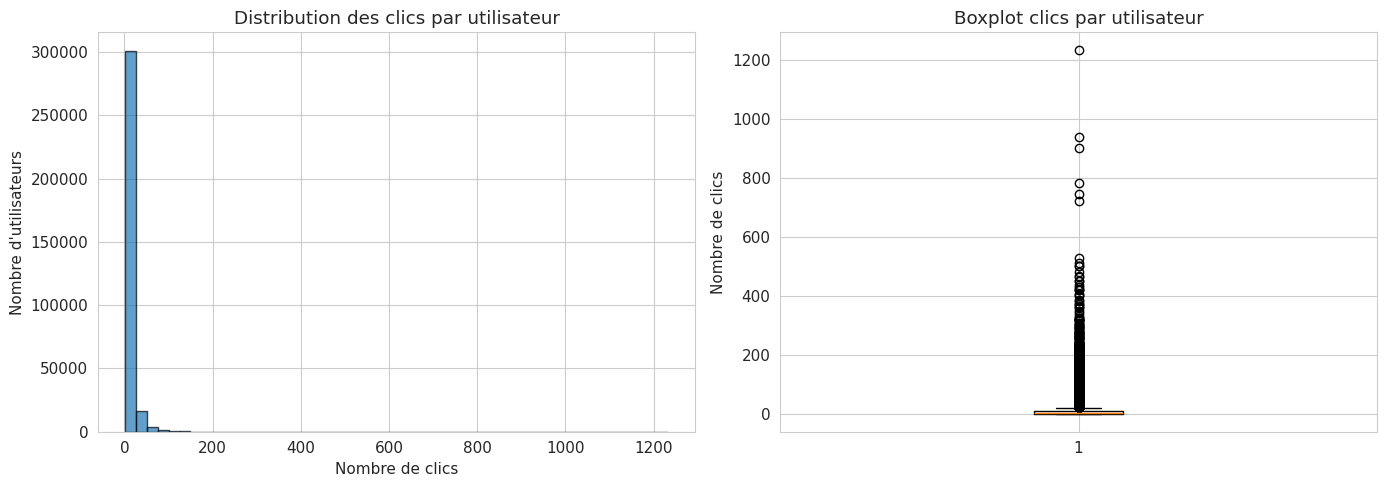

count    322897.000000
mean          9.254285
std          14.946358
min           2.000000
25%           2.000000
50%           4.000000
75%          10.000000
max        1232.000000
Name: nb_clicks, dtype: float64


In [7]:
clicks_per_user = clicks.groupby("user_id").size().reset_index(name="nb_clicks")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clicks_per_user["nb_clicks"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Nombre de clics")
axes[0].set_ylabel("Nombre d'utilisateurs")
axes[0].set_title("Distribution des clics par utilisateur")

axes[1].boxplot(clicks_per_user["nb_clicks"], vert=True)
axes[1].set_ylabel("Nombre de clics")
axes[1].set_title("Boxplot clics par utilisateur")

plt.tight_layout()
plt.savefig(os.path.join(FIG, "dist_clicks_per_user.png"), dpi=150, bbox_inches="tight")
plt.show()

print(clicks_per_user["nb_clicks"].describe())

### 5.2 Utilisateurs les plus actifs


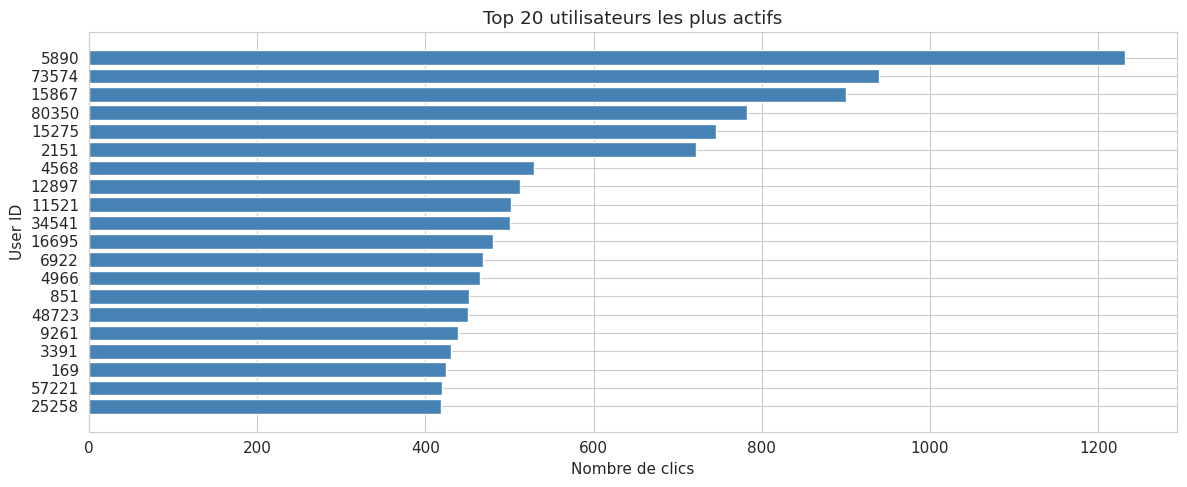

In [8]:
top_users = clicks_per_user.nlargest(20, "nb_clicks")

plt.figure(figsize=(12, 5))
plt.barh(top_users["user_id"].astype(str), top_users["nb_clicks"], color="steelblue")
plt.xlabel("Nombre de clics")
plt.ylabel("User ID")
plt.title("Top 20 utilisateurs les plus actifs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "top_users.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Analyse des articles


### 6.1 Distribution de popularite des articles


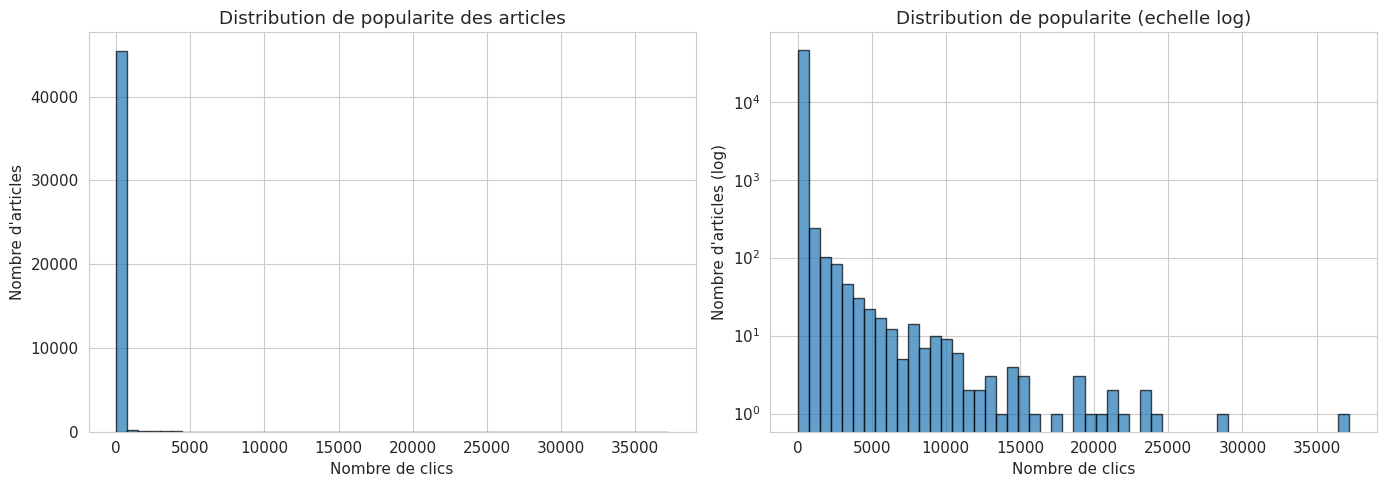

count    46033.000000
mean        64.913888
std        629.322888
min          1.000000
25%          1.000000
50%          1.000000
75%          6.000000
max      37213.000000
Name: nb_clicks, dtype: float64


In [9]:
clicks_per_article = clicks.groupby("click_article_id").size().reset_index(name="nb_clicks")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clicks_per_article["nb_clicks"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Nombre de clics")
axes[0].set_ylabel("Nombre d'articles")
axes[0].set_title("Distribution de popularite des articles")

# Log scale pour mieux voir la longue traine
axes[1].hist(clicks_per_article["nb_clicks"], bins=50, edgecolor="black", alpha=0.7, log=True)
axes[1].set_xlabel("Nombre de clics")
axes[1].set_ylabel("Nombre d'articles (log)")
axes[1].set_title("Distribution de popularite (echelle log)")

plt.tight_layout()
plt.savefig(os.path.join(FIG, "dist_article_popularity.png"), dpi=150, bbox_inches="tight")
plt.show()

print(clicks_per_article["nb_clicks"].describe())

### 6.2 Top articles et longue traine


In [10]:
top_articles = clicks_per_article.nlargest(20, "nb_clicks")
top_articles_meta = top_articles.merge(articles, left_on="click_article_id", right_on="article_id", how="left")
print(top_articles_meta[["click_article_id", "nb_clicks", "category_id", "words_count"]])

# Part du top 10% des articles dans les clics totaux
top_10pct = int(len(clicks_per_article) * 0.1)
sorted_articles = clicks_per_article.sort_values("nb_clicks", ascending=False)
top_share = sorted_articles.head(top_10pct)["nb_clicks"].sum() / sorted_articles["nb_clicks"].sum()
print(f"\nLes {top_10pct} articles les plus populaires (top 10%) representent {top_share:.1%} des clics")

    click_article_id  nb_clicks  category_id  words_count
0             160974      37213          281          259
1             272143      28943          399          184
2             336221      23851          437          158
3             234698      23499          375          183
4             123909      23122          250          240
5             336223      21855          437          122
6              96210      21577          209          274
7             162655      21062          281          245
8             183176      20303          301          285
9             168623      19526          297          157
10            331116      18788          436          144
11            158536      18646          281          858
12             64329      18618          134          199
13            199198      17221          323          221
14            272660      16175          399          246
15            235616      15443          375          220
16            

### 6.3 Distribution par categorie


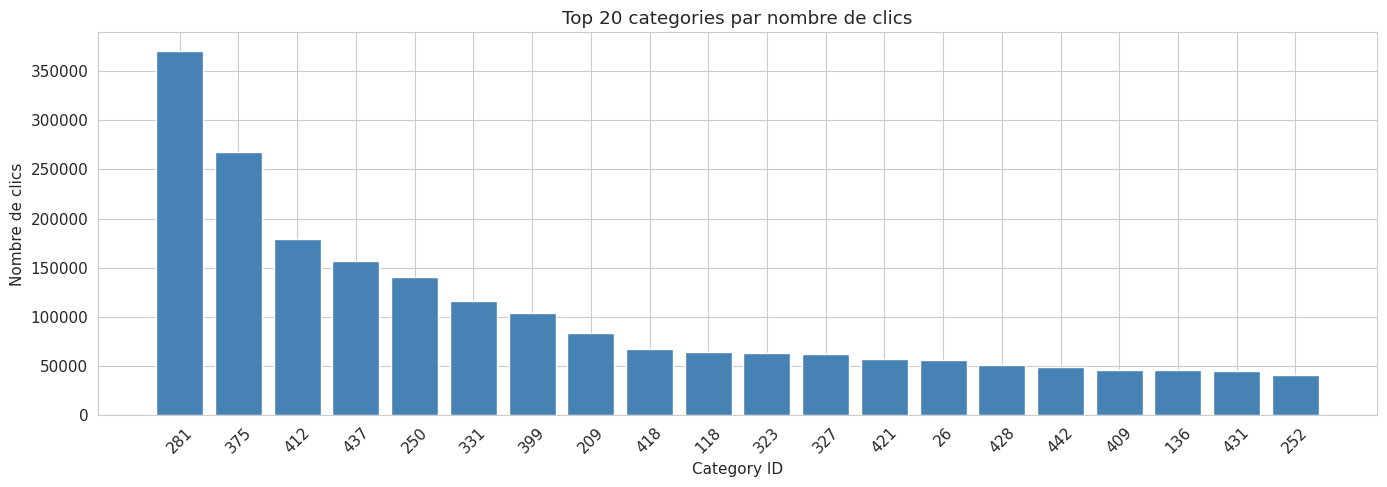

In [11]:
# Enrichir clicks avec les metadonnees
clicks_enriched = clicks.merge(articles, left_on="click_article_id", right_on="article_id", how="left")

cat_counts = clicks_enriched.groupby("category_id").size().reset_index(name="nb_clicks")
cat_counts = cat_counts.sort_values("nb_clicks", ascending=False)

plt.figure(figsize=(14, 5))
top_cats = cat_counts.head(20)
plt.bar(top_cats["category_id"].astype(str), top_cats["nb_clicks"], color="steelblue")
plt.xlabel("Category ID")
plt.ylabel("Nombre de clics")
plt.title("Top 20 categories par nombre de clics")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "top_categories.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.4 Distribution du nombre de mots par article


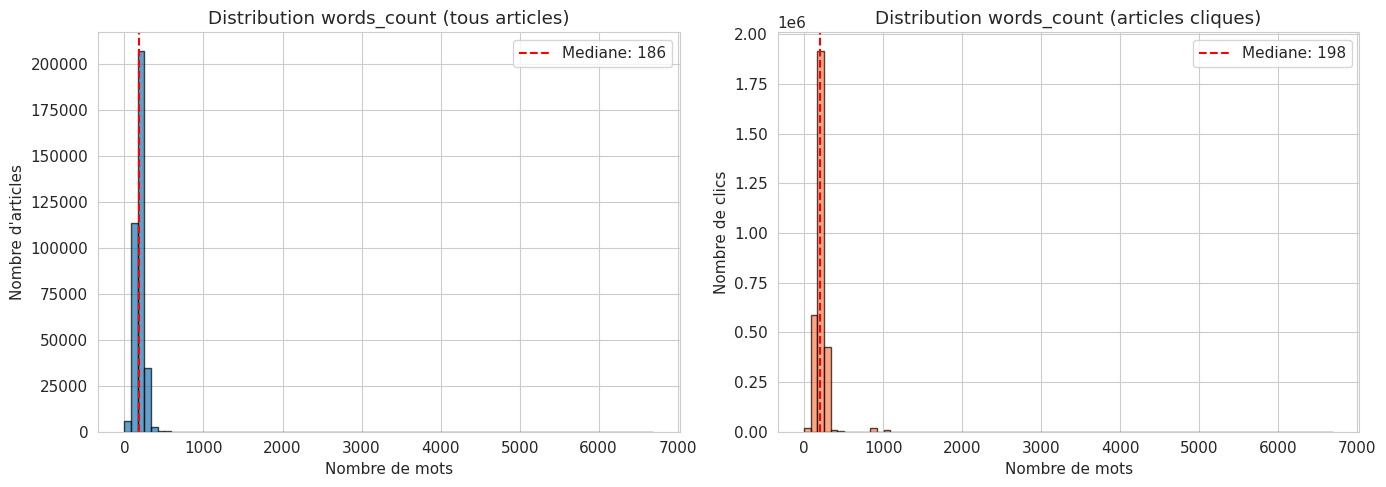

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Articles de la base complete
axes[0].hist(articles["words_count"], bins=80, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Nombre d'articles")
axes[0].set_title("Distribution words_count (tous articles)")
axes[0].axvline(articles["words_count"].median(), color="red", linestyle="--", label=f"Mediane: {articles['words_count'].median():.0f}")
axes[0].legend()

# Articles effectivement cliques
clicked_wc = clicks_enriched["words_count"].dropna()
axes[1].hist(clicked_wc, bins=80, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("Nombre de clics")
axes[1].set_title("Distribution words_count (articles cliques)")
axes[1].axvline(clicked_wc.median(), color="red", linestyle="--", label=f"Mediane: {clicked_wc.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG, "dist_words_count.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Analyse temporelle


### 7.1 Volume de clics par heure


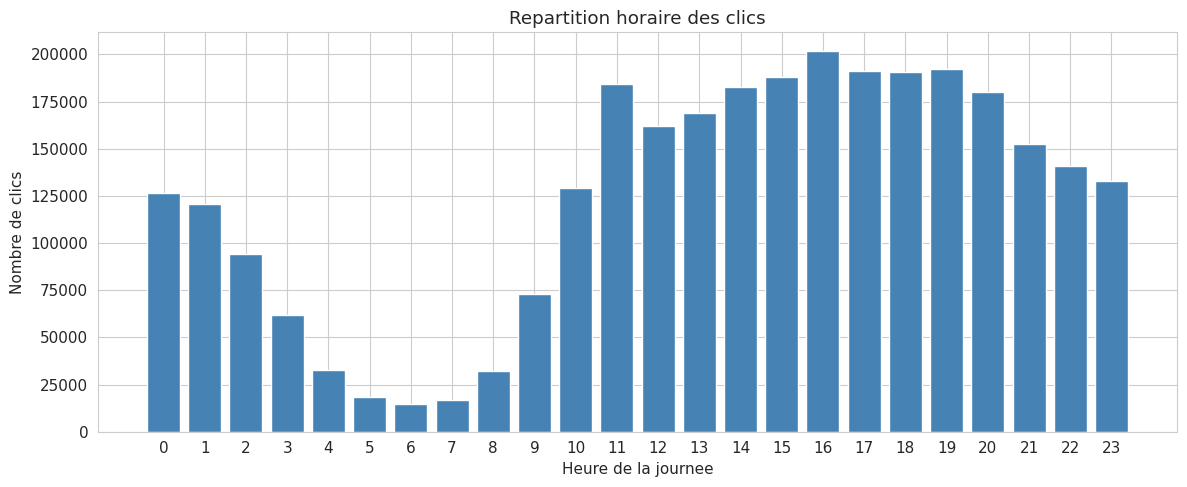

In [13]:
hourly = clicks.groupby("click_hour").size().reset_index(name="nb_clicks")

plt.figure(figsize=(12, 5))
plt.bar(hourly["click_hour"], hourly["nb_clicks"], color="steelblue")
plt.xlabel("Heure de la journee")
plt.ylabel("Nombre de clics")
plt.title("Repartition horaire des clics")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(os.path.join(FIG, "clicks_by_hour.png"), dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Volume par jour


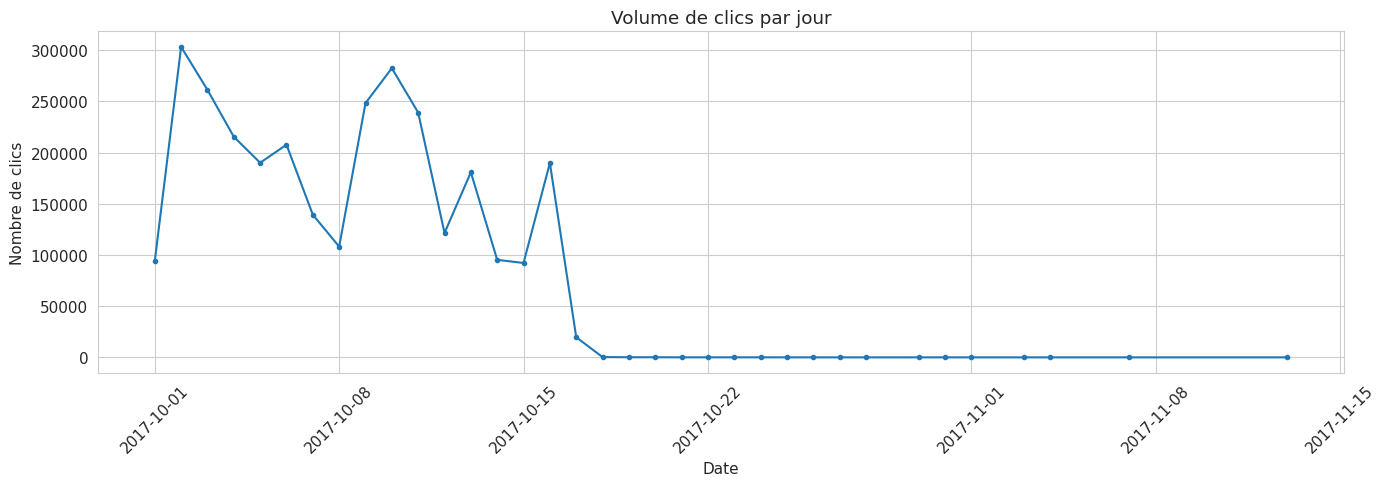

In [14]:
daily = clicks.groupby("click_day").size().reset_index(name="nb_clicks")

plt.figure(figsize=(14, 5))
plt.plot(daily["click_day"], daily["nb_clicks"], marker="o", markersize=3)
plt.xlabel("Date")
plt.ylabel("Nombre de clics")
plt.title("Volume de clics par jour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "clicks_by_day.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Analyse des sessions


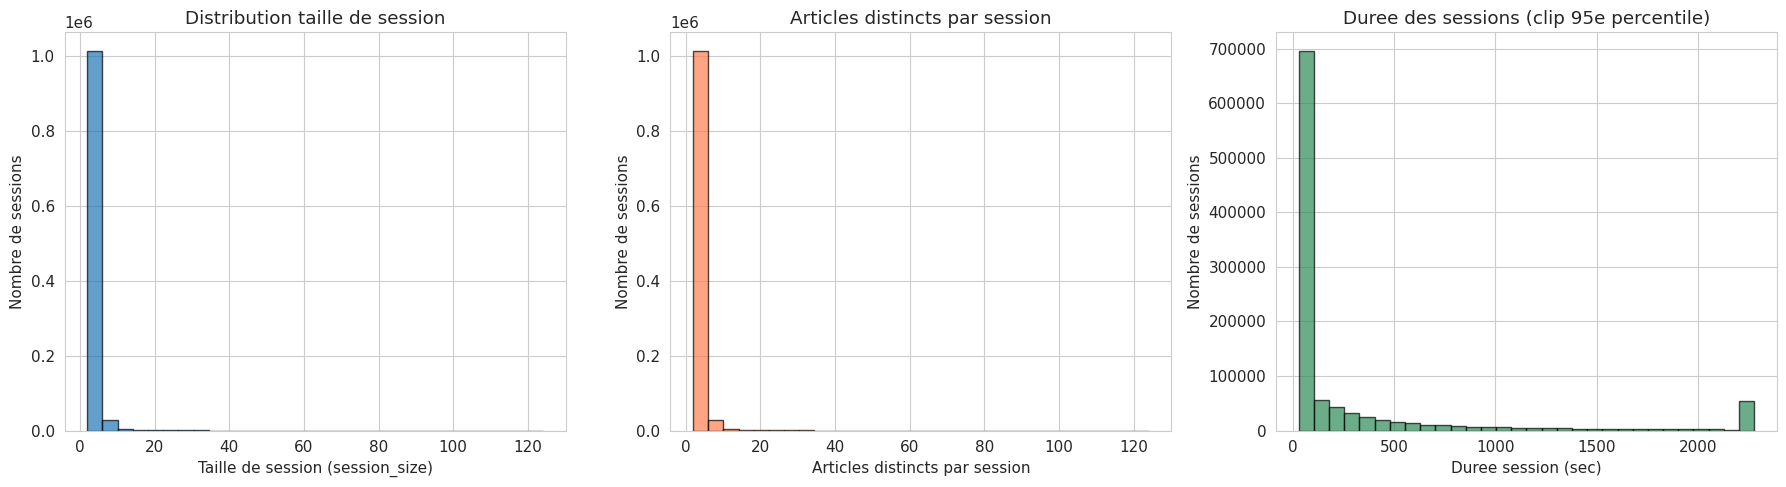

       nb_clicks  nb_articles_distincts  duree_sec
count  1048594.0              1048594.0  1048594.0
mean         2.8                    2.8      836.9
std          1.7                    1.7    10684.3
min          2.0                    2.0       30.0
25%          2.0                    2.0       30.0
50%          2.0                    2.0       30.0
75%          3.0                    3.0      238.8
max        124.0                  124.0  2362404.8


In [24]:
session_stats = clicks.groupby("session_id").agg(
    user_id=("user_id", "first"),
    session_size=("session_size", "first"),
    nb_clicks=("click_article_id", "count"),
    nb_articles_distincts=("click_article_id", "nunique"),
    duree_sec=("click_timestamp", lambda x: (x.max() - x.min()) / 1000)
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(session_stats["session_size"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Taille de session (session_size)")
axes[0].set_ylabel("Nombre de sessions")
axes[0].set_title("Distribution taille de session")

axes[1].hist(session_stats["nb_articles_distincts"], bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("Articles distincts par session")
axes[1].set_ylabel("Nombre de sessions")
axes[1].set_title("Articles distincts par session")

axes[2].hist(session_stats["duree_sec"].clip(upper=session_stats["duree_sec"].quantile(0.95)),
             bins=30, edgecolor="black", alpha=0.7, color="seagreen")
axes[2].set_xlabel("Duree session (sec)")
axes[2].set_ylabel("Nombre de sessions")
axes[2].set_title("Duree des sessions (clip 95e percentile)")

plt.tight_layout()
plt.savefig(os.path.join(FIG, "session_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()



session_desc = session_stats[["session_size", "nb_clicks", "nb_articles_distincts", "duree_sec"]].describe()
session_desc = session_desc.round(1)
pd.set_option("display.float_format", lambda x: f"{x:.1f}")
print(session_desc)
pd.reset_option("display.float_format")

## 9. Exploration des embeddings


In [16]:
if embeddings is not None:
    print(f"Dimensions embeddings : {embeddings.shape}")
    print(f"Type de donnees : {embeddings.dtypes.unique() if hasattr(embeddings, 'dtypes') else type(embeddings)}")
    
    # Verifier la correspondance avec les articles
    if hasattr(embeddings, 'index'):
        emb_ids = set(embeddings.index)
    else:
        emb_ids = set(range(len(embeddings)))
    
    clicked_ids = set(clicks["click_article_id"].unique())
    all_article_ids = set(articles["article_id"].unique())
    
    print(f"\nArticles avec embedding : {len(emb_ids):,}")
    print(f"Articles cliques couverts par embeddings : {len(clicked_ids & emb_ids)} / {len(clicked_ids)}")
    print(f"Articles totaux couverts par embeddings : {len(all_article_ids & emb_ids)} / {len(all_article_ids)}")
else:
    print("Embeddings non charges")

Dimensions embeddings : (364047, 250)
Type de donnees : <class 'numpy.ndarray'>

Articles avec embedding : 364,047
Articles cliques couverts par embeddings : 46033 / 46033
Articles totaux couverts par embeddings : 364047 / 364047


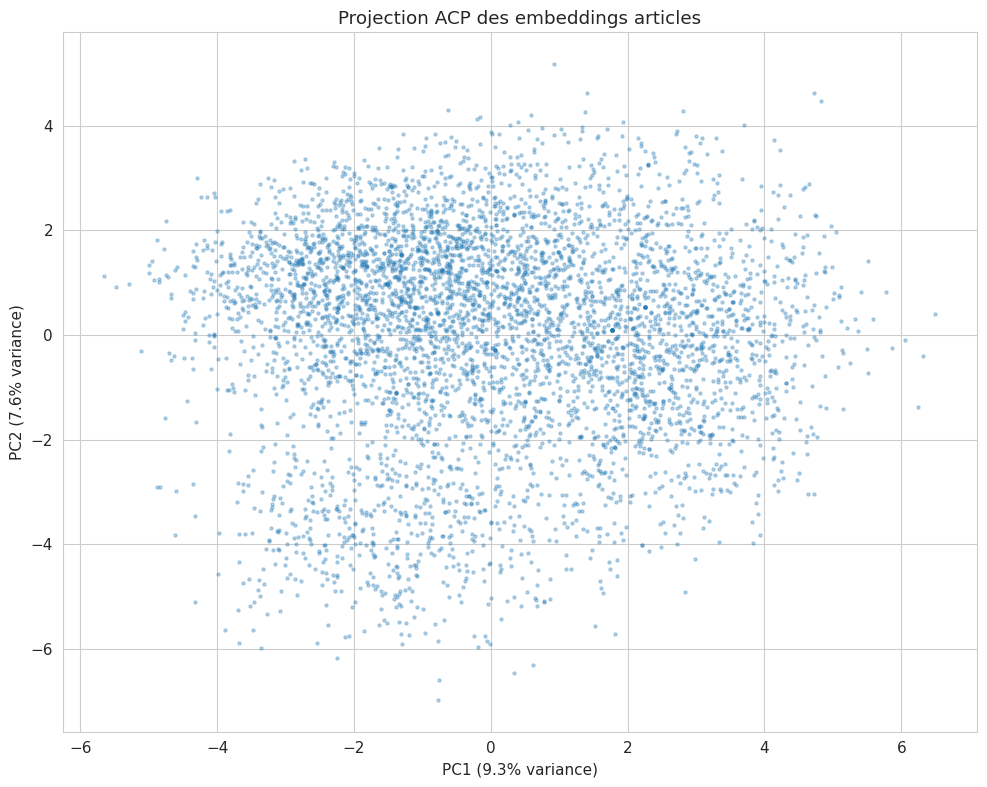

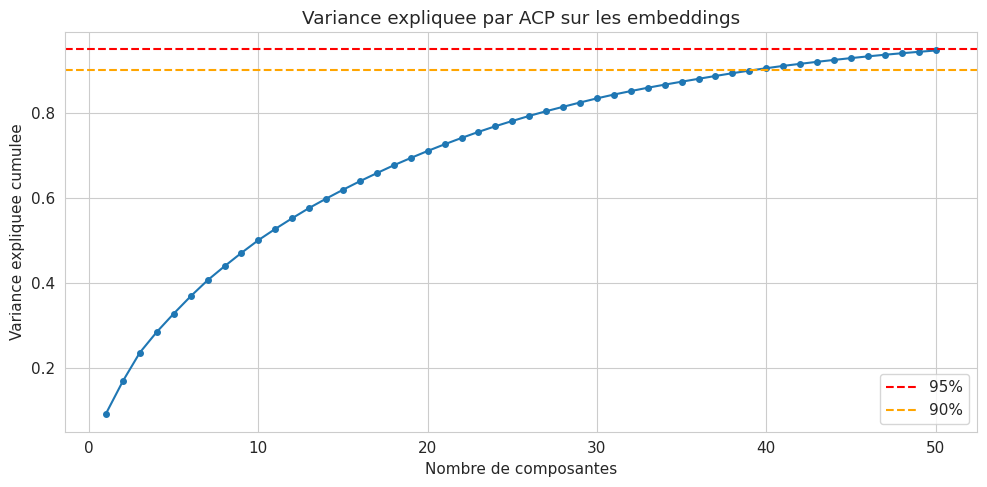

Composantes pour 90% de variance : 40
Composantes pour 95% de variance : 1


In [17]:
if embeddings is not None:
    from sklearn.decomposition import PCA
    
    # Reduction ACP pour visualisation
    emb_values = embeddings.values if hasattr(embeddings, 'values') else embeddings
    
    # Sous-echantillon si trop gros
    sample_size = min(5000, len(emb_values))
    idx = np.random.choice(len(emb_values), sample_size, replace=False)
    emb_sample = emb_values[idx]
    
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb_sample)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.3, s=5)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.title("Projection ACP des embeddings articles")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, "embeddings_pca.png"), dpi=150, bbox_inches="tight")
    plt.show()
    
    # Variance expliquee cumulee
    pca_full = PCA(n_components=min(50, emb_sample.shape[1]))
    pca_full.fit(emb_sample)
    
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumvar) + 1), cumvar, marker="o", markersize=4)
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquee cumulee")
    plt.title("Variance expliquee par ACP sur les embeddings")
    plt.axhline(y=0.95, color="red", linestyle="--", label="95%")
    plt.axhline(y=0.90, color="orange", linestyle="--", label="90%")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, "embeddings_pca_variance.png"), dpi=150, bbox_inches="tight")
    plt.show()
    
    n_95 = np.argmax(cumvar >= 0.95) + 1
    n_90 = np.argmax(cumvar >= 0.90) + 1
    print(f"Composantes pour 90% de variance : {n_90}")
    print(f"Composantes pour 95% de variance : {n_95}")

## 10. Matrice d'interaction user-article


In [18]:
# Matrice binaire : l'utilisateur a-t-il clique sur l'article ?
interaction = clicks.groupby(["user_id", "click_article_id"]).size().reset_index(name="nb_clicks")

print(f"Interactions uniques (user, article) : {len(interaction):,}")
print(f"Densite matrice : {len(interaction) / (n_users * n_articles_clicked) * 100:.2f}%")
print(f"Interactions min par paire : {interaction['nb_clicks'].min()}")
print(f"Interactions max par paire : {interaction['nb_clicks'].max()}")

# Distribution des re-lectures
relecture = interaction[interaction["nb_clicks"] > 1]
print(f"\nPaires avec re-lecture (>1 clic) : {len(relecture)} ({len(relecture)/len(interaction)*100:.1f}%)")

Interactions uniques (user, article) : 2,950,710
Densite matrice : 0.02%
Interactions min par paire : 1
Interactions max par paire : 33

Paires avec re-lecture (>1 clic) : 33875 (1.1%)


### Visualisation de la matrice creuse (sous-echantillon)


Matrice creuse : (322897, 46033)
Elements non-nuls : 2950710
Densite : 0.02%


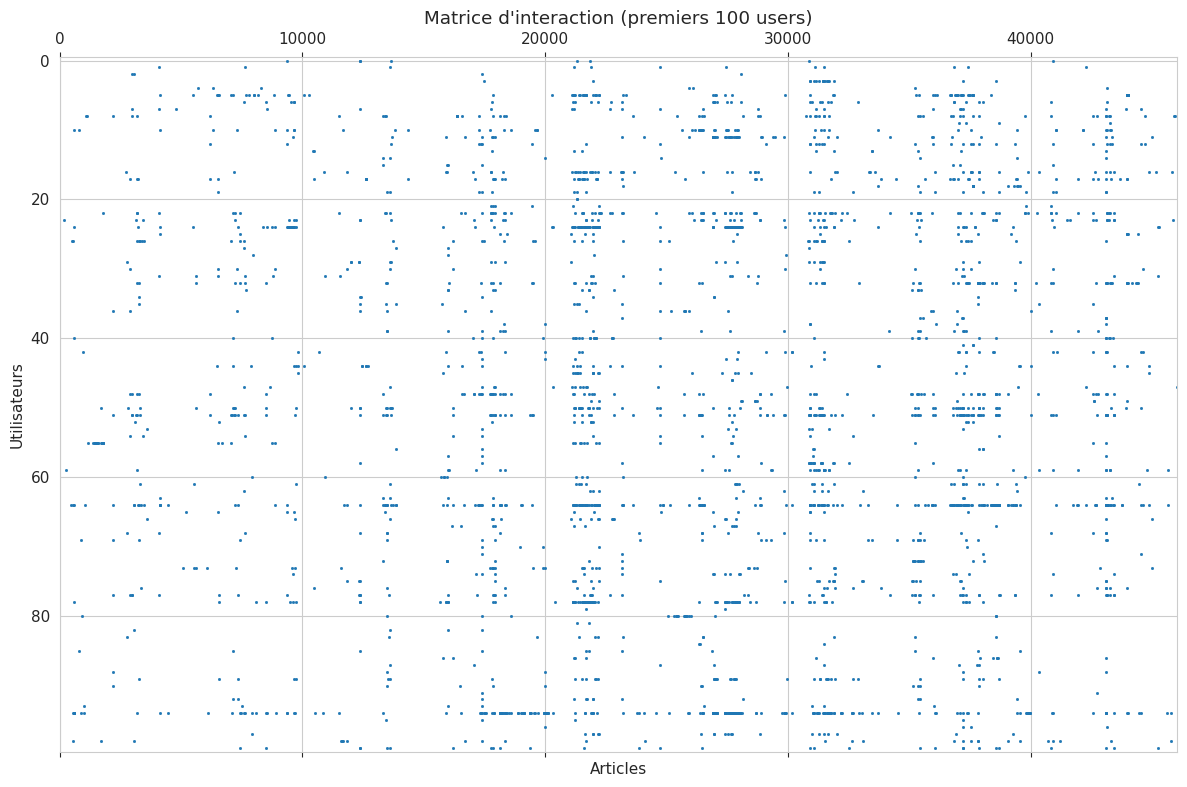

In [19]:
from scipy.sparse import csr_matrix

# Construction matrice creuse
user_ids = clicks["user_id"].unique()
article_ids = clicks["click_article_id"].unique()

user_map = {u: i for i, u in enumerate(sorted(user_ids))}
article_map = {a: i for i, a in enumerate(sorted(article_ids))}

rows = clicks["user_id"].map(user_map).values
cols = clicks["click_article_id"].map(article_map).values
data = np.ones(len(clicks))

sparse_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_map), len(article_map)))
print(f"Matrice creuse : {sparse_matrix.shape}")
print(f"Elements non-nuls : {sparse_matrix.nnz}")
print(f"Densite : {sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]) * 100:.2f}%")

# Visualisation sous-echantillon
sample_n = min(100, sparse_matrix.shape[0])
plt.figure(figsize=(12, 8))
plt.spy(sparse_matrix[:sample_n, :], markersize=1, aspect="auto")
plt.xlabel("Articles")
plt.ylabel("Utilisateurs")
plt.title(f"Matrice d'interaction (premiers {sample_n} users)")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "interaction_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Analyse du contexte utilisateur


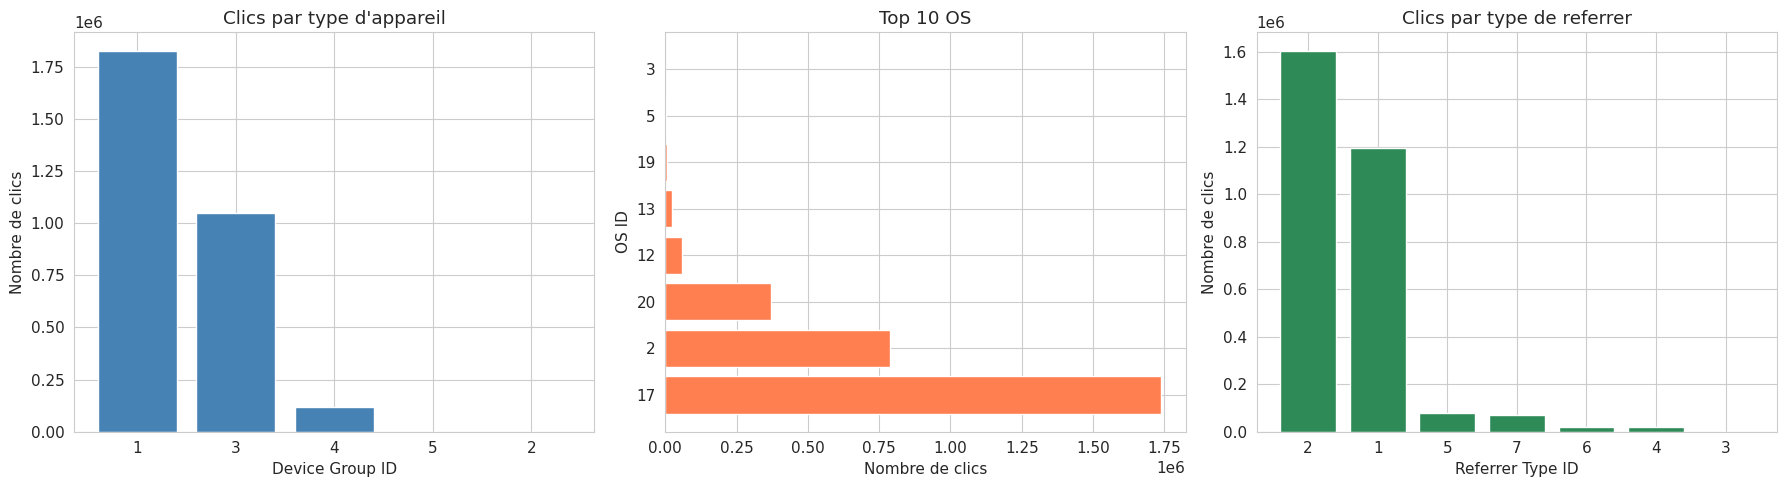

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Device group
device_counts = clicks["click_deviceGroup"].value_counts()
axes[0].bar(device_counts.index.astype(str), device_counts.values, color="steelblue")
axes[0].set_xlabel("Device Group ID")
axes[0].set_ylabel("Nombre de clics")
axes[0].set_title("Clics par type d'appareil")

# OS
os_counts = clicks["click_os"].value_counts().head(10)
axes[1].barh(os_counts.index.astype(str), os_counts.values, color="coral")
axes[1].set_xlabel("Nombre de clics")
axes[1].set_ylabel("OS ID")
axes[1].set_title("Top 10 OS")

# Referrer type
ref_counts = clicks["click_referrer_type"].value_counts()
axes[2].bar(ref_counts.index.astype(str), ref_counts.values, color="seagreen")
axes[2].set_xlabel("Referrer Type ID")
axes[2].set_ylabel("Nombre de clics")
axes[2].set_title("Clics par type de referrer")

plt.tight_layout()
plt.savefig(os.path.join(FIG, "context_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Sauvegarde des donnees preparees


In [21]:
# Sauvegarder les donnees nettoyees pour les scripts suivants
clicks_enriched.to_parquet(os.path.join(DATA_PROC, "clicks_enriched.parquet"), index=False)
interaction.to_parquet(os.path.join(DATA_PROC, "interactions.parquet"), index=False)

# Sauvegarder les mappings
import json
with open(os.path.join(DATA_PROC, "user_map.json"), "w") as f:
    json.dump({str(k): v for k, v in user_map.items()}, f)
with open(os.path.join(DATA_PROC, "article_map.json"), "w") as f:
    json.dump({str(k): v for k, v in article_map.items()}, f)

print("Donnees sauvegardees dans data/processed/")
print(f"  clicks_enriched.parquet : {len(clicks_enriched):,} lignes")
print(f"  interactions.parquet : {len(interaction):,} lignes")
print(f"  user_map.json : {len(user_map)} users")
print(f"  article_map.json : {len(article_map)} articles")

Donnees sauvegardees dans data/processed/
  clicks_enriched.parquet : 2,988,181 lignes
  interactions.parquet : 2,950,710 lignes
  user_map.json : 322897 users
  article_map.json : 46033 articles
